# Load spatialdata object

In [2]:
import anndata as ad
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import matplotlib.pyplot as plt

/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


We read the MIBI-tof data. We use spatialdata readers for this

In [3]:
sdata=sd.read_zarr('../../../data/IMC.zarr')

/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


This object contains many example images, with 40 channels, and corresponding labels. All info of segmented cells is condensed into a single anndata 

In [6]:
sdata

SpatialData object, with associated Zarr store: /Users/sergio/Documents/jnotebooks/sprot_hackathon/data/IMC.zarr
├── Images
│     ├── 'Patient1_001_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient1_002_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient1_003_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient2_001_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient2_002_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient2_003_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient2_004_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient3_001_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient3_002_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient3_003_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient4_005_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient4_006_image': DataArray[cyx] (40, 600, 600)
│     ├── 'Patient4_007_image': DataArray[cyx] (40, 600, 600)
│     └── 'Patient4_008_image': DataArray[cyx] (40, 600, 600)
├── Labe

We can see how the info of segmented cells looks like. Image can be used to divide by patient

In [8]:
sdata['table'].obs

,area,centroid-0,centroid-1,axis_major_length,axis_minor_length,eccentricity,image,image_width_px,image_height_px,image_num_channels,...,image_acquisition_id,image_acquisition_description,image_acquisition_start_x_um,image_acquisition_start_y_um,image_acquisition_end_x_um,image_acquisition_end_y_um,image_acquisition_width_um,image_acquisition_height_um,cell_id,region
Object 1 in Patient1_001.tiff,12,0.416667,468.583333,7.406234,1.895294,0.966702,Patient1_001.tiff,600,600,40,...,1,pos1_1,37500.828,17756.254,38100.828,17156.254,600.0,600.0,1,Patient1_001_labels
Object 2 in Patient1_001.tiff,24,0.416667,515.833333,16.480040,1.962838,0.992882,Patient1_001.tiff,600,600,40,...,1,pos1_1,37500.828,17756.254,38100.828,17156.254,600.0,600.0,2,Patient1_001_labels
Object 3 in Patient1_001.tiff,17,0.470588,587.235294,9.850849,1.985817,0.979470,Patient1_001.tiff,600,600,40,...,1,pos1_1,37500.828,17756.254,38100.828,17156.254,600.0,600.0,3,Patient1_001_labels
Object 4 in Patient1_001.tiff,24,1.250000,192.250000,8.082904,3.915780,0.874818,Patient1_001.tiff,600,600,40,...,1,pos1_1,37500.828,17756.254,38100.828,17156.254,600.0,600.0,4,Patient1_001_labels
Object 5 in Patient1_001.tiff,22,0.909091,231.772727,8.793666,3.116532,0.935091,Patient1_001.tiff,600,600,40,...,1,pos1_1,37500.828,17756.254,38100.828,17156.254,600.0,600.0,5,Patient1_001_labels
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 2841 in Patient4_008.tiff,47,597.255319,357.680851,12.607573,5.160594,0.912389,Patient4_008.tiff,600,600,40,...,8,pos1_4,27702.627,7195.411,28302.627,6595.411,600.0,600.0,2841,Patient4_008_labels
Object 2842 in Patient4_008.tiff,17,597.764706,367.058824,5.415619,3.980897,0.677984,Patient4_008.tiff,600,600,40,...,8,pos1_4,27702.627,7195.411,28302.627,6595.411,600.0,600.0,2842,Patient4_008_labels
Object 2843 in Patient4_008.tiff,41,597.731707,136.341463,13.102653,4.112542,0.949466,Patient4_008.tiff,600,600,40,...,8,pos1_4,27702.627,7195.411,28302.627,6595.411,600.0,600.0,2843,Patient4_008_labels
Object 2844 in Patient4_008.tiff,24,597.833333,232.291667,7.790156,4.103809,0.849993,Patient4_008.tiff,600,600,40,...,8,pos1_4,27702.627,7195.411,28302.627,6595.411,600.0,600.0,2844,Patient4_008_labels


We can extract image info using the following code. The name of channels is not very infomative, but we have this info in sdata['table'].var as channel name

In [14]:
img_array=sdata['Patient1_001_image'].values
channel_name=sdata['table'].var.index
print(channel_name)

Index(['MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR', 'CD27', 'CD15',
       'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3', 'LAG3 / LAG33',
       'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7', 'CD45RO',
       'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67', 'VISTA',
       'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP', 'DNA1',
       'DNA2'],
      dtype='object')


We have some basic visualization

In [13]:

import matplotlib.pyplot as plt

def plot_channels(img_array, channel_names, roi=None, cmap="Greys"):
    """
    Plot multiple channels from a numpy image array in subplots.

    Parameters
    ----------
    img_array : np.ndarray
        Shape (channels, y, x)
    channel_names : list of str
        Names of channels to plot
    roi : tuple or None
        (x_min, x_max, y_min, y_max) in pixel coordinates. If None, plot full image.
    cmap : str
        Colormap for imshow
    """
    n_channels = len(channel_names)
    fig, axes = plt.subplots(1, n_channels, figsize=(4*n_channels, 4))

    if n_channels == 1:
        axes = [axes]  # ensure iterable

    for ax, idx in zip(axes, range(n_channels)):
        # Extract channel
        ch_img = img_array[idx, :, :]

        # Apply ROI
        if roi is not None:
            x_min, x_max, y_min, y_max = roi
            ch_img = ch_img[y_min:y_max, x_min:x_max]

        ax.imshow(ch_img, cmap=cmap)
        ax.set_title(channel_names[idx])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


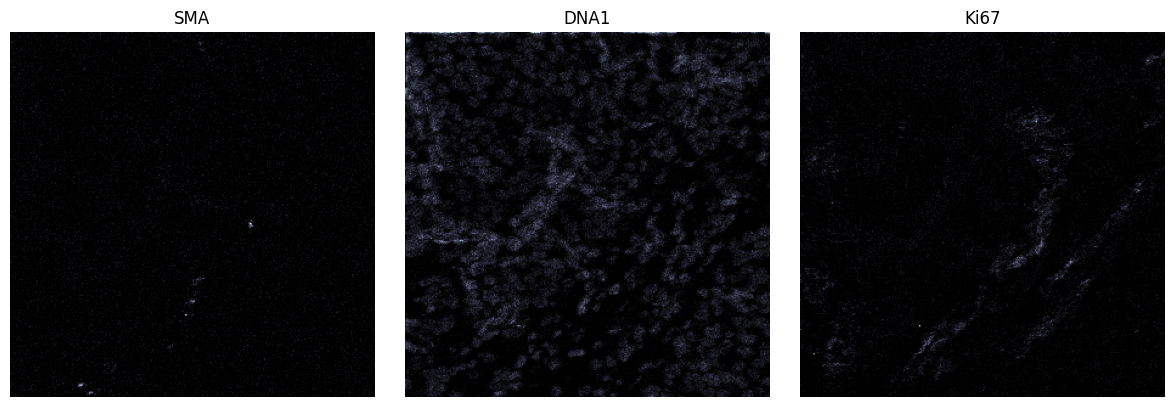

In [21]:
img_array = sdata['Patient1_001_image'].data  # numpy array
channels = ["SMA","DNA1","Ki67"]
roi=(0,300,0,300)

plot_channels(img_array, channels,roi=roi, cmap='bone')


array(['DNA_6', 'ELANE', 'CD57', 'CD45', 'DNA_7', 'CD11B', 'SMA', 'CD16',
       'DNA_8', 'ECAD', 'FOXP3', 'NCAM'], dtype='<U5')

# Data distribution

In [23]:
adata=sdata['table']

In [24]:
adata.var.index

Index(['MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR', 'CD27', 'CD15',
       'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3', 'LAG3 / LAG33',
       'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7', 'CD45RO',
       'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67', 'VISTA',
       'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP', 'DNA1',
       'DNA2'],
      dtype='object')

In [25]:
import matplotlib.pyplot as plt

def plot_gene_histogram(adata, gene, bins=100):
    """
    Plot histogram of expression values for one gene/channel in adata.

    Parameters
    ----------
    adata : AnnData
        AnnData object
    gene : str
        Gene name in adata.var.index
    bins : int
        Number of histogram bins
    """
    if gene not in adata.var.index:
        raise ValueError(f"{gene} not found in adata.var.index")

    # Get expression values for this gene
    values = adata[:, gene].X

    # If sparse, convert to dense
    if not hasattr(values, "toarray"):
        values = values
    else:
        values = values.toarray().flatten()

    plt.hist(values, bins=bins, color="steelblue", edgecolor="steelblue")
    plt.title(f"Expression distribution for {gene}")
    plt.xlabel("Expression value")
    plt.ylabel("Cell count")
    plt.show()


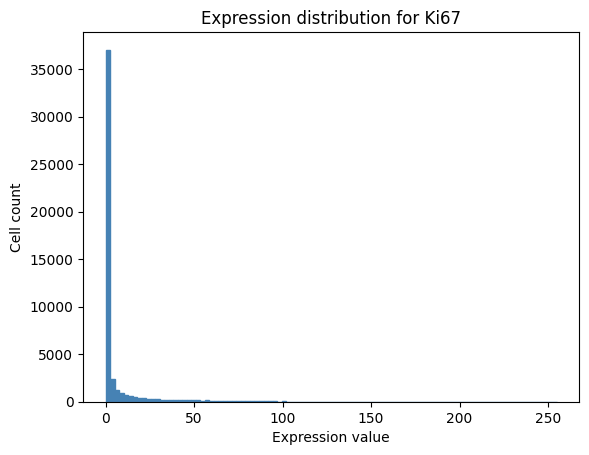

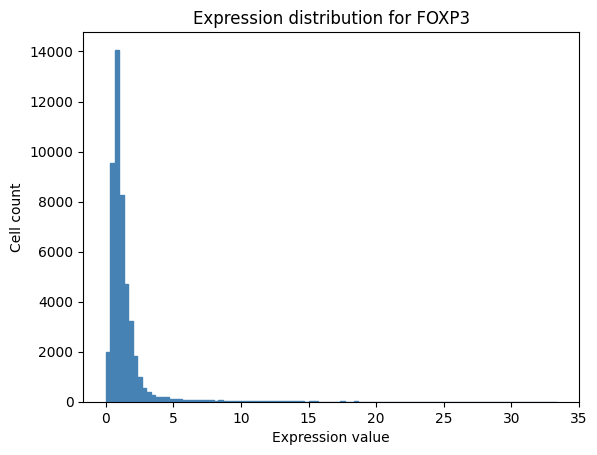

In [ ]:
plot_gene_histogram(adata, "Ki67")
plot_gene_histogram(adata, "FOXP3")
